In [1]:
from transformers import BitsAndBytesConfig, AutoModelForSeq2SeqLM, AutoTokenizer
import torch

In [ ]:
model_name = "C:\\Users\\Happy\\SRP\\SRP Project MT training\\mt_training\\models\\t5-small-separated-100k_final_100000"

tokenizer = AutoTokenizer.from_pretrained("t5-small")

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)



In [3]:
def inference_fp32(tokenizer, text, model_name, num_return_sequences=1, num_beams=10):
    model_fp32 = AutoModelForSeq2SeqLM.from_pretrained(
        model_name,
        torch_dtype=torch.float32,
        device_map="auto",
    ).to("cuda")

    inputs = tokenizer(text, return_tensors="pt", return_token_type_ids=False).to(model_fp32.device)
    outputs = model_fp32.generate(
        **inputs, 
        max_length=256, 
        repetition_penalty=1.0, 
        do_sample=False, 
        num_return_sequences=num_return_sequences, 
        num_beams=num_beams, 
        output_scores=True, 
        return_dict_in_generate=True
    )

    preds_fp32 = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)
    return preds_fp32

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

In [26]:
text = "OB(O)c1ccc(C(F)(F)F)cc1.CCOC(=O)c1ccccc1S(N)(=O)=O>CC(=O)[O-].CC(=O)[O-].[Cu+2].Cc1cccc(C)n1.ClCCCl,CCOC(=O)c1ccccc1S(=O)(=O)Nc1ccc(C(F)(F)F)cc1>CCOC(=O)c1ccccc1S(=O)(=O)N(c1ccc(C(F)(F)F)cc1)c1ccc(C(F)(F)F)cc1"
text_list = text.split(",")

inp = text_list[0]
ground_truth = text_list[1]

inp, ground_truth

('OB(O)c1ccc(C(F)(F)F)cc1.CCOC(=O)c1ccccc1S(N)(=O)=O>CC(=O)[O-].CC(=O)[O-].[Cu+2].Cc1cccc(C)n1.ClCCCl',
 'CCOC(=O)c1ccccc1S(=O)(=O)Nc1ccc(C(F)(F)F)cc1>CCOC(=O)c1ccccc1S(=O)(=O)N(c1ccc(C(F)(F)F)cc1)c1ccc(C(F)(F)F)cc1')

Reactants

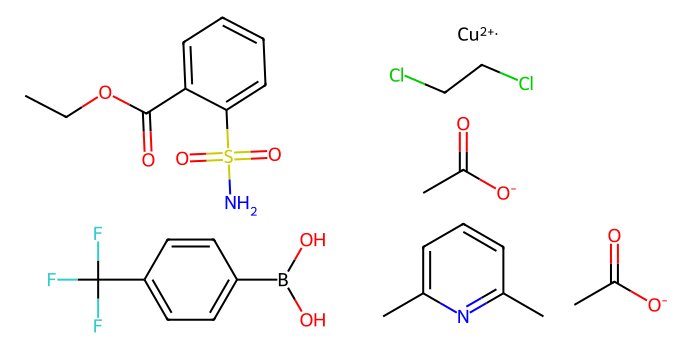

In [27]:
mol_inps = inp.split(">")
mols = [Chem.MolFromSmiles(s) for s in mol_inps]

img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=2,
    subImgSize=(350, 350)
)
img

Products ground truth

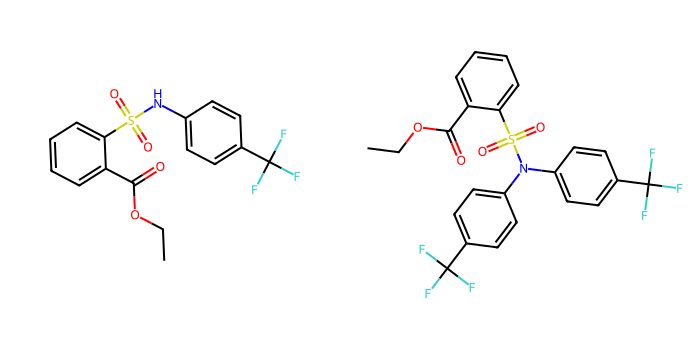

In [28]:
mol_ground_truths = ground_truth.split(">")
mols = [Chem.MolFromSmiles(s) for s in mol_ground_truths]

img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=2,
    subImgSize=(350,350)
)
img

Predictions

In [10]:
inp = "Predict the product of this reaction: CSc1nccc(-c2c[nH]nc2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1.N#CCBr>CN(C)C=O.O=C([O-])[O-].[K+].[K+]"

['CCOC(=O)c1ccccc1-c1ccc(C(F)(F)F)cc1', 'CCOC(=O)c1ccc(-c2ccc(C(F)(F)F)cc2)cc1S(N)(=O)=O', 'CCOC(=O)c1ccccc1S(=O)(=O)Nc1ccc(C(F)(F)F)cc1', 'CCOC(=O)c1ccc(-c2ccc(C(F)(F)F)cc2)cc1S(=O)(=O)N', 'CCOC(=O)c1cccc(-c2ccc(C(F)(F)F)cc2)c1S(N)(=O)=O', 'CCOC(=O)c1ccc(-c2ccc(C(F)(F)F)cc2)cc1S(=O)(=O)NC(=O)c1ccccc1', 'CCOC(=O)c1ccccc1S(=O)(=O)N=C(c1ccc(C(F)(F)F)cc1)c1ccccc1', 'CCOC(=O)c1ccccc1S(=O)(=O)NC(=O)c1ccc(C(F)(F)F)cc1', 'CCOC(=O)c1ccccc1S(=O)(=O)N(c1ccc(C(F)(F)F)cc1)c1ccccc1', 'CCOC(=O)c1ccc(-c2ccc(C(F)(F)F)cc2)cc1S(=O)(=O)NC(=O)OCC']


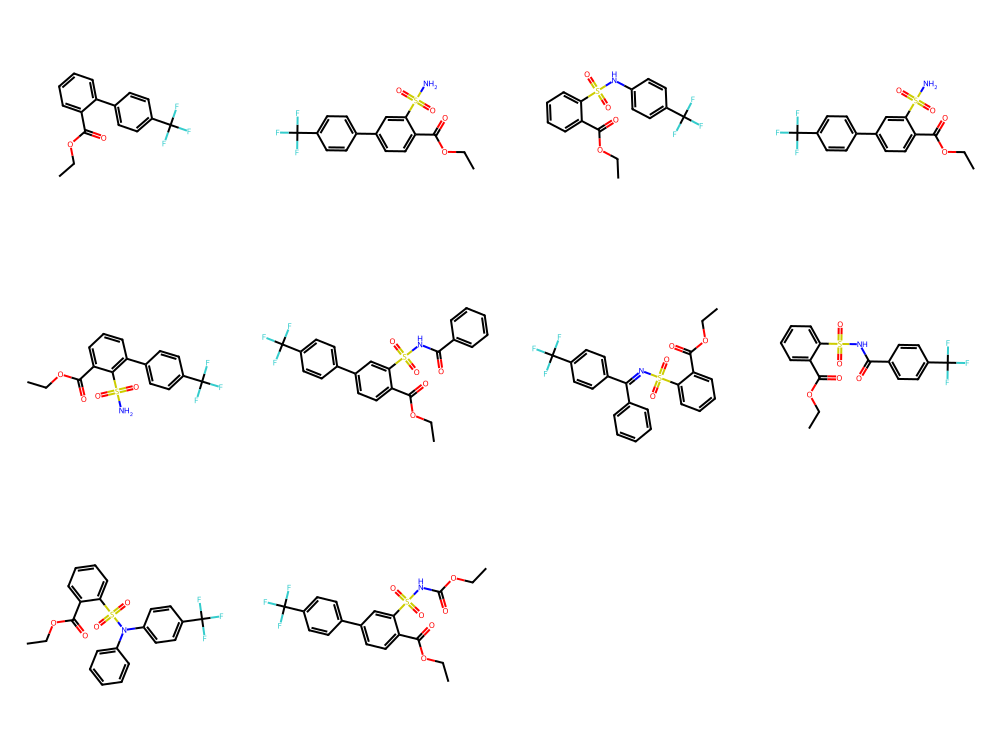

In [32]:
mol_fp32 = inference_fp32(tokenizer, inp, model_name, num_return_sequences=10, num_beams=10)

print(mol_fp32)

# raise Exception("stop")

smiles = mol_fp32
mols = [Chem.MolFromSmiles(s) for s in smiles]

img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=4,
    subImgSize=(250,250)
)
img

OLD

In [ ]:
# def inference_4bit(tokenizer, text, model_name, num_return_sequences=1, num_beams=10):
#     bnb_config = BitsAndBytesConfig(
#         load_in_4bit=True,
#         bnb_4bit_use_double_quant=True,
#         bnb_4bit_quant_type="nf4",
#         bnb_4bit_compute_dtype="float16",
#     )

#     model_4bit = AutoModelForSeq2SeqLM.from_pretrained(
#         model_name,
#         quantization_config=bnb_config,
#         device_map="auto",
#     ).to("cuda")

#     inputs = tokenizer(text, return_tensors="pt", return_token_type_ids=False).to(model_4bit.device)
#     outputs = model_4bit.generate(
#         **inputs, 
#         max_length=256, 
#         repetition_penalty=1.0, 
#         do_sample=False, 
#         num_return_sequences=num_return_sequences, 
#         num_beams=num_beams, 
#         output_scores=True, 
#         return_dict_in_generate=True
#     )

#     preds_4bit = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)
#     return preds_4bit[0]

# def inference_8bit(tokenizer, text, model_name, num_return_sequences=1, num_beams=10):
#     bnb_config = BitsAndBytesConfig(
#         load_in_8bit=True,
#     )

#     model_8bit = AutoModelForSeq2SeqLM.from_pretrained(
#         model_name,
#         quantization_config=bnb_config,
#         device_map="auto",
#     )

#     inputs = tokenizer(text, return_tensors="pt", return_token_type_ids=False).to(model_8bit.device)
#     outputs = model_8bit.generate(
#         **inputs, 
#         max_length=256, 
#         repetition_penalty=1.0, 
#         do_sample=False, 
#         num_return_sequences=num_return_sequences, 
#         num_beams=num_beams, 
#         output_scores=True, 
#         return_dict_in_generate=True
#     )

#     preds_8bit = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)
#     return preds_8bit[0]

# def inference_fp16(tokenizer, text, model_name, num_return_sequences=1, num_beams=10):
#     model_fp16 = AutoModelForSeq2SeqLM.from_pretrained(
#         model_name,
#         torch_dtype=torch.float16,
#         device_map="auto",
#     ).to("cuda")

#     inputs = tokenizer(text, return_tensors="pt", return_token_type_ids=False).to(model_fp16.device)
#     outputs = model_fp16.generate(
#         **inputs, 
#         max_length=256, 
#         repetition_penalty=1.0, 
#         do_sample=False, 
#         num_return_sequences=num_return_sequences, 
#         num_beams=num_beams, 
#         output_scores=True, 
#         return_dict_in_generate=True
#     )

#     preds_fp16 = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)
#     return preds_fp16[0]